# Durability: Composition vs Mass Change under Etching

**Features:** Pt, Pd, Au, Ir (atomic fractions)  
**Targets:** per-element mass change after the 3 h chronoamperometry hold (`dm_*`, mg/cm²) and the total absolute alloy change (`dm_total_abs`), from `data/composition_durability.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_predict

import warnings

warnings.filterwarnings('ignore')

SEED = 42
X_COLS = ['Pt', 'Pd', 'Au', 'Ir']
ALLOY = ['Pt', 'Pd', 'Au', 'Ir']

DURABILITY_CSV = 'data/composition_durability.csv'
CORROSION_XLSX = 'data/external/corrosion.xlsx'

# Chronoamperometry hold parameters used for the Faradaic budget
HOLD_SECONDS = 3 * 3600  # 3 h etching hold
J_OER = 0.010  # A/cm², the eta_10 reference current density
FARADAY = 96485.0  # C/mol
M_AU = 196.97  # g/mol
Z_AU = 3  # Au -> Au(III); the generous (worst) case

## 1. Load

In [2]:
df = pd.read_csv(DURABILITY_CSV)
print(f'Samples: {len(df)}')
df

Samples: 6


,Pt,Pd,Au,Ir,dm_Pt,dm_Pd,dm_Au,dm_Ir,dm_Si,dm_total_abs,run
0,0.3275,0.1510,0.4458,0.0758,-0.0013,0.0006,-0.0033,-0.0004,0.0130,0.0056,run9-22
1,0.6525,0.1073,0.2393,0.0009,-0.0012,0.0007,-0.0003,-0.0006,0.0100,0.0028,run9-34
2,0.1599,0.2450,0.4481,0.1471,-0.0010,-0.0024,-0.0007,-0.0024,0.0338,0.0065,run10-9
3,0.5665,0.0950,0.3169,0.0216,0.0000,0.0028,-0.0027,-0.0003,0.0074,0.0058,run10-34
4,0.0417,0.1253,0.3351,0.4979,0.0006,0.0012,-0.0051,-0.0007,0.0068,0.0076,run11-12
5,0.0628,0.1019,0.5044,0.3309,-0.0004,0.0018,-0.0065,-0.0042,0.0261,0.0129,run11-18


## 2. Etching Pattern

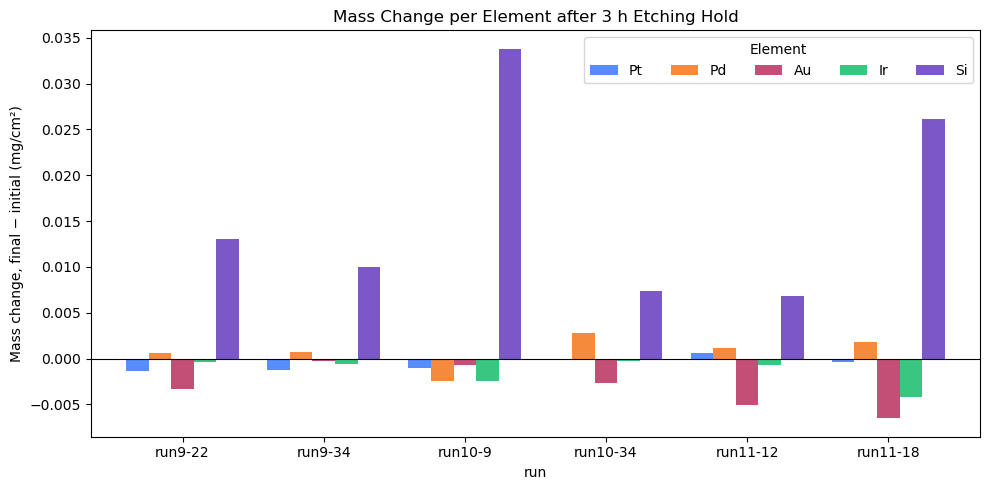

Sign pattern across runs (negative = etched away):
          Pt  Pd  Au  Ir  Si
run                         
run9-22   -1   1  -1  -1   1
run9-34   -1   1  -1  -1   1
run10-9   -1  -1  -1  -1   1
run10-34   0   1  -1  -1   1
run11-12   1   1  -1  -1   1
run11-18  -1   1  -1  -1   1


In [3]:
# Etching pattern per run: which elements lose mass, which gain
dm_cols = ['dm_Pt', 'dm_Pd', 'dm_Au', 'dm_Ir', 'dm_Si']
plot_df = df.set_index('run')[dm_cols]
plot_df.columns = ['Pt', 'Pd', 'Au', 'Ir', 'Si']

fig, ax = plt.subplots(figsize=(10, 5))
plot_df.plot.bar(ax=ax, width=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mass change, final − initial (mg/cm²)')
ax.set_title('Mass Change per Element after 3 h Etching Hold')
ax.legend(title='Element', ncols=5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/durability_mass_change.png', dpi=300)
plt.show()

print('Sign pattern across runs (negative = etched away):')
print(np.sign(plot_df).astype(int).to_string())

## 3. Fraction of Gold Etched

Tests the expectation that Au etches off the surface early but totals only ~10% of the Au loading by 3 h.

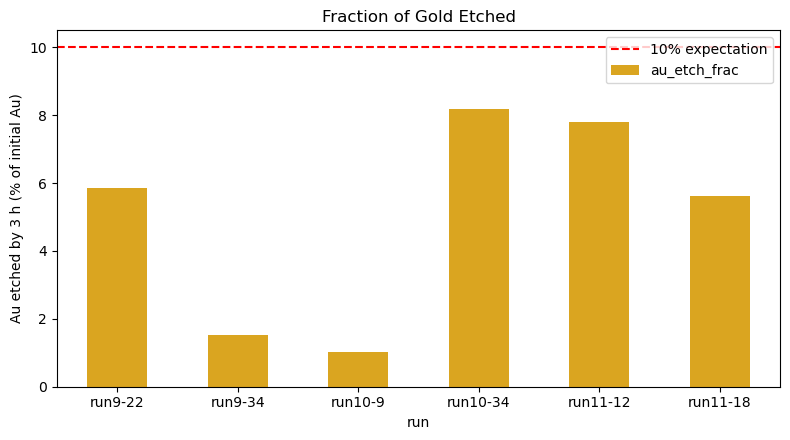

Au etched by 3 h: median 5.7% | max 8.2% (all below the ~10% expectation)
dm_Au vs initial Au mass: r = -0.749 (p = 0.087); the more Au present, the more etches, consistent with a roughly constant etched fraction rather than a fixed absolute loss.


In [4]:
# ── How much of the gold actually etched? ────────────────────
# The expectation: Au etches off the surface quickly but amounts to less than
# ~10% of the Au loading by 3 h. Initial masses come from the corrosion
# sheet, so the etched fraction is dm_Au / initial Au.
raw = pd.read_excel(CORROSION_XLSX, header=None).rename(
    columns={0: 'run', 1: 'rowtype'}
)
raw['run'] = raw['run'].ffill()
is_init = raw['rowtype'].astype(str).str.strip().str.lower() == 'initial'
initial = raw[is_init].set_index('run')[[2, 3, 4, 5]].astype(float)
initial.columns = [f'{el}_init' for el in ALLOY]

m = df.set_index('run').join(initial)
m['au_etch_frac'] = -m['dm_Au'] / m['Au_init']

fig, ax = plt.subplots(figsize=(8, 4.5))
(100 * m['au_etch_frac']).plot.bar(ax=ax, color='goldenrod')
ax.axhline(10, color='red', linestyle='--', label='10% expectation')
ax.set_ylabel('Au etched by 3 h (% of initial Au)')
ax.set_title('Fraction of Gold Etched')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/durability_au_etch_fraction.png', dpi=300)
plt.show()

r, p = stats.pearsonr(m['Au_init'], m['dm_Au'])
print(
    f'Au etched by 3 h: median {100 * m["au_etch_frac"].median():.1f}% | '
    f'max {100 * m["au_etch_frac"].max():.1f}% (all below the ~10% '
    f'expectation)'
)
print(
    f'dm_Au vs initial Au mass: r = {r:+.3f} (p = {p:.3f}); the more Au '
    f'present, the more etches, consistent with a roughly constant '
    f'etched fraction rather than a fixed absolute loss.'
)

## 4. Faradaic Budget — Is the Current OER?

Converts the etched gold to its charge equivalent and compares it to the charge a genuine OER hold passes.

In [5]:
# ── Faradaic budget: is the anodic current OER or Au etching? ─
# If the measured current were gold dissolution rather than OER, the
# charge passed would have to match the gold that left the surface.
# Convert each run's Au loss to its charge equivalent via Faraday's law
# (Au -> Au³⁺, z = 3, the case most generous to etching) and compare it
# to the charge a genuine OER hold passes.
au_loss_g = (-m['dm_Au'].clip(upper=0)) * 1e-3  # mg -> g per cm²
#Note: Z_AU is the electron count per dissolved atom in Faraday's Law:
# Q = (m/M) * z * F, Z_AU = 3 is the maximum possible for gold (conservative).
q_etch = au_loss_g / M_AU * Z_AU * FARADAY  # C/cm²
j_equiv = q_etch / HOLD_SECONDS * 1e6  # µA/cm²

q_oer = J_OER * HOLD_SECONDS  # C/cm² at eta_10
share = 100 * q_etch / q_oer

budget = pd.DataFrame(
    {
        'dm_Au (mg/cm²)': m['dm_Au'],
        'Q_etch (C/cm²)': q_etch.round(4),
        'j_equiv (µA/cm²)': j_equiv.round(2),
        'share of OER charge (%)': share.round(4),
    }
)
print(budget.to_string())
print(
    f'\nOER charge at {1000 * J_OER:.0f} mA/cm² for 3 h: {q_oer:.0f} ' f'C/cm²'
)
print(
    f'Au etching share of that charge: median '
    f'{share.median():.4f}%, max {share.max():.4f}%'
)

# Reductio ad Absurdum: all-alloy upper bound, every metal lost, charged at z = 4
alloy_loss_g = sum((-m[f'dm_{el}'].clip(upper=0)) * 1e-3 for el in ALLOY)
q_all = alloy_loss_g / 190.0 * 4 * FARADAY  # ~molar mass of the metals
print(
    f'All-alloy dissolution bound (z = 4): max '
    f'{100 * (q_all / q_oer).max():.3f}% of the OER charge'
)
print(
    '\nConclusion: even attributing every microgram of metal loss to '
    'electrochemical dissolution, etching supplies well under 0.1% of '
    'the anodic charge; the measured current is OER, and Au etching '
    'is a negligible contributor to it.'
)

          dm_Au (mg/cm²)  Q_etch (C/cm²)  j_equiv (µA/cm²)  share of OER charge (%)
run                                                                                
run9-22          -0.0033          0.0048              0.45                   0.0045
run9-34          -0.0003          0.0004              0.04                   0.0004
run10-9          -0.0007          0.0010              0.10                   0.0010
run10-34         -0.0027          0.0040              0.37                   0.0037
run11-12         -0.0051          0.0075              0.69                   0.0069
run11-18         -0.0065          0.0096              0.88                   0.0088

OER charge at 10 mA/cm² for 3 h: 108 C/cm²
Au etching share of that charge: median 0.0041%, max 0.0088%
All-alloy dissolution bound (z = 4): max 0.021% of the OER charge

Conclusion: even attributing every microgram of metal loss to electrochemical dissolution, etching supplies well under 0.1% of the anodic charge; the measur

## 5. Leave-One-Out ML

      Target            Model  LOO Q2
       dm_Au  Ridge (alpha=1)   0.837
       dm_Au Ridge (alpha=10)   0.387
       dm_Au        KNN (k=2)   0.280
dm_total_abs  Ridge (alpha=1)  -0.077
dm_total_abs Ridge (alpha=10)   0.335
dm_total_abs        KNN (k=2)   0.318


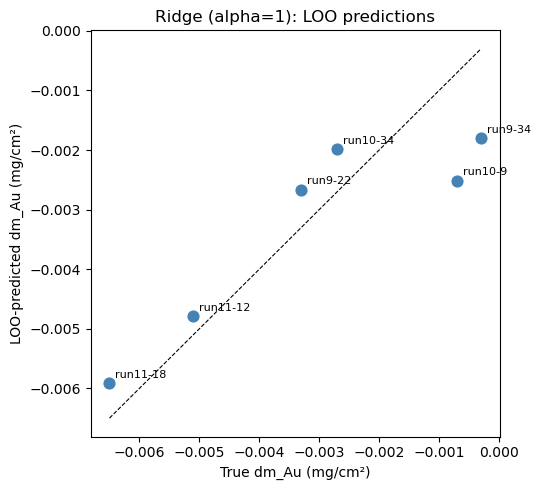

In [6]:
# ── ML: composition -> mass change, honestly sized ───────────
# With only 6 runs, there are few options.
# I chose a LOOCV to compute a Q^2 score.
# Train on 5/6 runs, predict on hold out. Repeat for 5 more runs.
# Q² is skill relative to a
# leave-one-out mean baseline (Q² = 0 means no better than predicting
# the mean; negative means worse; 1 is perfect).
X = df[X_COLS].to_numpy(float)
loo = LeaveOneOut()

candidates = {
    'Ridge (alpha=1)': Pipeline(
        [('sc', StandardScaler()), ('m', Ridge(alpha=1.0))]
    ),
    'Ridge (alpha=10)': Pipeline(
        [('sc', StandardScaler()), ('m', Ridge(alpha=10.0))]
    ),
    'KNN (k=2)': Pipeline(
        [('sc', StandardScaler()), ('m', KNeighborsRegressor(2))]
    ),
}

rows = []
loo_preds = {}
for target in ['dm_Au', 'dm_total_abs']:
    y = df[target].to_numpy(float)
    press_base = np.sum(
        [(y[i] - np.delete(y, i).mean()) ** 2 for i in range(len(y))]
    )
    for name, model in candidates.items():
        pred = cross_val_predict(model, X, y, cv=loo)
        #q2 is r^2 on held-out predictions
        q2 = 1.0 - np.sum((pred - y) ** 2) / press_base
        rows.append({'Target': target, 'Model': name, 'LOO Q2': q2})
        loo_preds[(target, name)] = pred

print(pd.DataFrame(rows).round(3).to_string(index=False))

# Predicted vs true for the strongest target/model pair
best_target, best_name = 'dm_Au', 'Ridge (alpha=1)'
pred = loo_preds[(best_target, best_name)]
y = df[best_target].to_numpy(float)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(y, pred, s=60, color='steelblue')
for yi, pi, run in zip(y, pred, df['run']):
    ax.annotate(
        run, (yi, pi), fontsize=8, xytext=(4, 4), textcoords='offset points'
    )
lims = [min(y.min(), pred.min()), max(y.max(), pred.max())]
ax.plot(lims, lims, 'k--', linewidth=0.8) #y=x identity line
ax.set_xlabel('True dm_Au (mg/cm²)')
ax.set_ylabel('LOO-predicted dm_Au (mg/cm²)')
ax.set_title(f'{best_name}: LOO predictions')
plt.tight_layout()
plt.savefig('images/durability_loocv.png', dpi=300)
plt.show()

## 6. Composition and Stability

Spearman rank correlations (n = 6):
      Target Element    rho     p
       dm_Au      Pt  0.771 0.072
       dm_Au      Pd  0.200 0.704
       dm_Au      Au -0.600 0.208
       dm_Au      Ir -0.771 0.072
dm_total_abs      Pt -0.886 0.019
dm_total_abs      Pd -0.086 0.872
dm_total_abs      Au  0.714 0.111
dm_total_abs      Ir  0.886 0.019


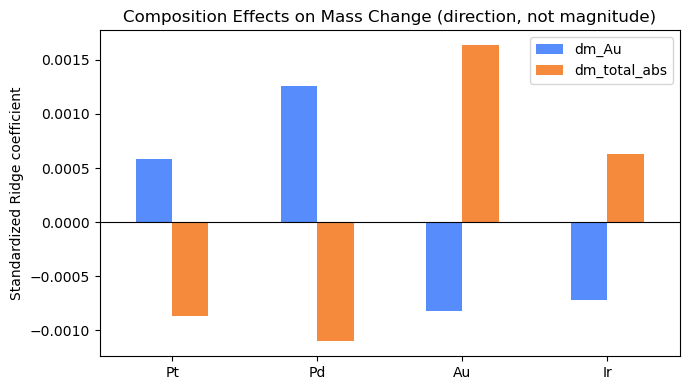


Reading (with n = 6 caution): Pt-rich compositions lose the least total alloy mass (rho = -0.89) and Ir-rich the most (rho = +0.89), consistent with Ir dissolution under OER conditions. dm_Au grows more negative with Au content, i.e. Au etches in proportion to its fraction, while Pt appears to stabilize the surface against both losses.


In [7]:
# ── Which elements stabilize the catalyst? ───────────────────
# Enriching one metal necessarily dilutes the others. Signs
# and rankings are meaningful here; precise magnitudes are not.
print('Spearman rank correlations (n = 6):')
rows = []
for target in ['dm_Au', 'dm_total_abs']:
    for feat in X_COLS:
        rho, p = stats.spearmanr(df[feat], df[target])
        rows.append({'Target': target, 'Element': feat, 'rho': rho, 'p': p})
corr = pd.DataFrame(rows)
print(corr.round(3).to_string(index=False))

ridge = Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0))])
coef_rows = {}
for target in ['dm_Au', 'dm_total_abs']:
    ridge.fit(X, df[target].to_numpy(float))
    coef_rows[target] = ridge.named_steps['m'].coef_
coefs = pd.DataFrame(coef_rows, index=X_COLS)

fig, ax = plt.subplots(figsize=(7, 4))
coefs.plot.bar(ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Standardized Ridge coefficient')
ax.set_title(
    'Composition Effects on Mass Change (direction, not ' 'magnitude)'
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/durability_coefficients.png', dpi=300)
plt.show()

print(
    '\nReading (with n = 6 caution): Pt-rich compositions lose the '
    'least total alloy mass (rho = -0.89) and Ir-rich the most '
    '(rho = +0.89), consistent with Ir dissolution under OER '
    'conditions. dm_Au grows more negative with Au content, i.e. Au '
    'etches in proportion to its fraction, while Pt appears to '
    'stabilize the surface against both losses.'
)